# Notebook 4: Using Cellular Automata to simulate physical dynamics
The aim of the first part of the notebook is not to keep building upon the fucntions defined earlier, but pause for a second and use the functions defined in the past to simulate 1-d wave interference.

The aim of the second part is to define block Cellular Automata and explain why they are so useful for simulating problems in physics.

In [17]:
import numpy as np

from itertools import permutations, product

In [18]:
from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

## 4.1) Recreating wave interference with rule 54

## 4.2) (Classical) Block Cellular Automata
### 4.2.1) How their evolution works
Block cellular Automata are a special type of CA that fixes the irreversibility issue of ordinary CA by construction.

In ordinary CA, each cell of the grid is updated individually given a the rule. In block CA, the lattice is divided into non-overlapping regions and the rule is applied to each region. In order to apply a rule to a region, you choose form a permutation and because permutattions are invertible, then the system is always invertible. An example, for blocks consising of two cells, would be the following:

{00,01,10,11}→{11,10,01,00}

### 4.2.2) Different types of evolution
Any evolution can be defined and its reversibility will depend on its construction, though all permutations will be reversible. There are examples of evolutions that are used frequently:
- identity: (a,b)→(a,b) 
- SWAP: (a,b)→(b,a) 
- XOR-into-first: (a,b)→(a⊕b, b)
- NOT-both: (a,b)→(¬a,¬b)

### 4.2.3) Different partition schemes
In one dimension, the partition schemes comes down only to how many cells you include in each block.

### 4.2.4) Coding the dynamics

In [19]:
def block_dynamics(initial_conditions, L, block_map, n_steps, block_size=2):
    assert L % block_size == 0, "L must be divisible by block_size"

    state = np.zeros(L, dtype=int)
    state[np.asarray(initial_conditions, dtype=int)] = 1

    grid = np.empty((n_steps + 1, L), dtype=int)
    grid[0] = state

    for t in range(n_steps):
        offset = t % block_size
        new_state = state.copy()
        for i in range(offset, L, block_size):
            idx = [(i + k) % L for k in range(block_size)]
            block_in = tuple(state[idx])
            block_out = block_map(block_in)
            for pos, val in zip(idx, block_out):
                new_state[pos] = val
        state = new_state
        grid[t + 1] = state

    return grid[::-1] # because the output is a numpy grid, then plotting will work with teh functions deined earlier

Now, we will define the block_map possibilities:

In [20]:
def identity_n(block):
    return block

def swap2(block):
    a, b = block
    return (b, a)

def xor_into_first(block):
    a, b = block
    return (a ^ b, b)

def not_both(block):
    a, b = block
    return (1 - a, 1 - b)

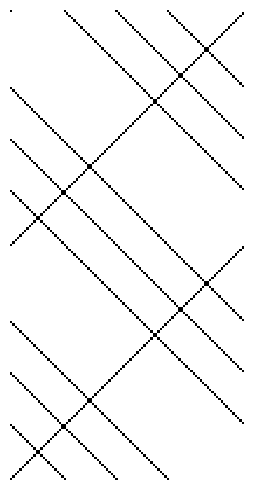

In [ ]:
system = block_dynamics([0,45,67,23], 100, swap2, 200)

plot_grid(system)

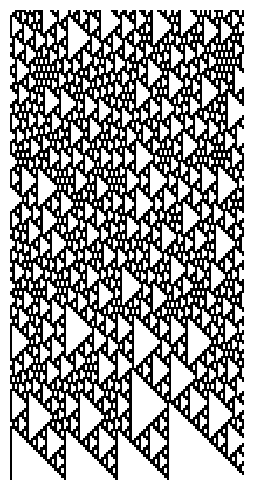

In [ ]:
system = block_dynamics([0,45,67,23], 100, xor_into_first, 200)

plot_grid(system)

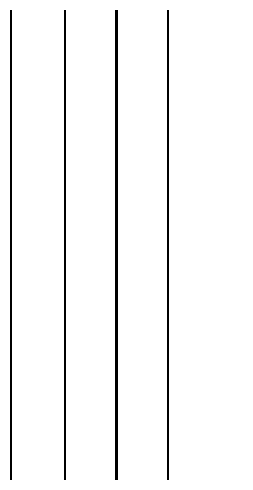

In [ ]:
system = block_dynamics([0,45,67,23], 100, identity_n, 200)

plot_grid(system)

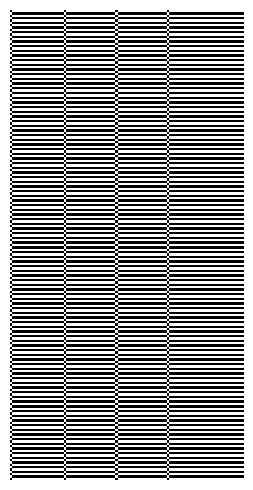

In [ ]:
system = block_dynamics([0,45,67,23], 100, not_both, 200)

plot_grid(system)

### 4.2.5) Modeling the dynamics of classical block Cellular Automata with matrices 

## 4.3) Probabilistic block Cellular Automata
### 4.3.1) Defining the dynamics
Following the definition from the previous notebook on randomized elementary Classical Automata, then a function describing a randomized version of block Cellular Automata would be the following:

In [25]:
def probabilistic_block_dynamics(initial_conditions, L, block_map, n_steps,
                             probability, block_size=2, rng=None):
    assert L % block_size == 0, "L must be divisible by block_size"
    if rng is None:
        rng = np.random.default_rng()

    state = np.zeros(L, dtype=int)
    state[np.asarray(initial_conditions, dtype=int)] = 1

    grid = np.empty((n_steps + 1, L), dtype=int)
    grid[0] = state

    for t in range(n_steps):
        offset = t % block_size
        new_state = state.copy()
        for i in range(offset, L, block_size):
            idx = [(i + k) % L for k in range(block_size)]
            block_in = tuple(state[idx])
            block_out = block_map(block_in)
            for pos, val in zip(idx, block_out):
                new_state[pos] = val

        # apply independent bit flips with probability flip_prob
        flips = rng.random(L) < probability
        new_state = np.where(flips, 1 - new_state, new_state)

        state = new_state
        grid[t + 1] = state

    return grid[::-1]

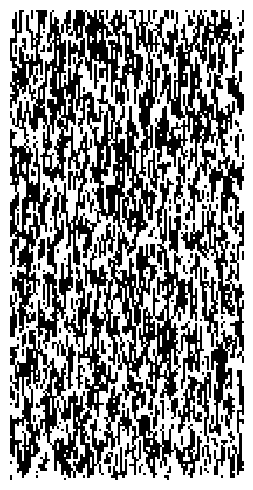

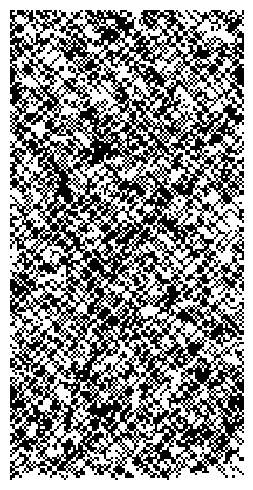

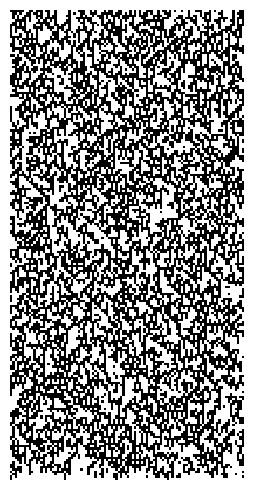

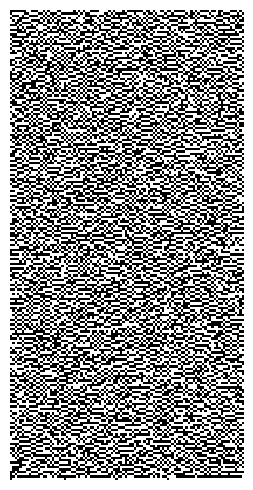

None None None None


In [27]:
system_1 = probabilistic_block_dynamics([0,45,67,23], 100, identity_n, 200, 0.2)
system_2 = probabilistic_block_dynamics([0,45,67,23], 100, swap2, 200, 0.2)
system_3 = probabilistic_block_dynamics([0,45,67,23], 100, xor_into_first, 200, 0.2)
system_4 = probabilistic_block_dynamics([0,45,67,23], 100, not_both, 200, 0.2)

print(plot_grid(system_1), plot_grid(system_2), plot_grid(system_3), plot_grid(system_4))

### 4.3.2) Dynamics of probabilistic block CA with matrices